In [1]:
library(readxl) ## Leer excel
library(tidyverse) ## Manipular base de datos
library(igraph) ## Grafos
library(expm) 
library(writexl)
library(ggraph)
library(tidygraph)  # para manipular grafos estilo tidy


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Adjuntando el paquete: 'igraph'


The following objects are masked from 'package:lubridate':

    %--%, union


The following objects are masked from 'package:dplyr':

    as_data_frame, groups, union


The following objects are masked from 'package:purrr':

    compose, simplify


The following object is masked from 'package:tidyr':

    crossing


The following object is masked from 'package:tibble':

    as_data_frame


The following objects are masked from 'package:s

In [59]:
# Lee un archivo Excel ubicado en la ruta especificada
matriz <- read_excel(
    "C:/Users/cfutr/OneDrive/Escritorio/CICS/2025/Tesis/Objetivos de Aprendizaje/Modelo/datos/Raw_Data/Matriz_de_Adyacencia_Pensiones_v5.xlsx", col_names=TRUE)

In [60]:
# Toma el data frame `matriz` (cargado desde un archivo Excel previamente)
# y lo transforma en una matriz de adyacencia numérica.

matriz_adj<-matriz%>%
  column_to_rownames(var = colnames(.)[1])%>% #Convierte la primera columna (por ejemplo, "Concepto") en los nombres de las filas.                         
  mutate(across(everything(), as.numeric)) %>%  #Aplica `as.numeric()` a todas las columnas del data frame.
  as.matrix() #Convierte el data frame limpio en una matriz

# Reemplaza todos los valores NA (valores perdidos) en la matriz de adyacencia `matriz_adj` por ceros.
matriz_adj[is.na(matriz_adj)] <- 0

# Crea un grafo dirigido (objeto de clase `igraph`) a partir de la matriz de adyacencia `matriz_adj`.
g <- graph_from_adjacency_matrix(matriz_adj, mode = "directed")

Using "stress" as default layout


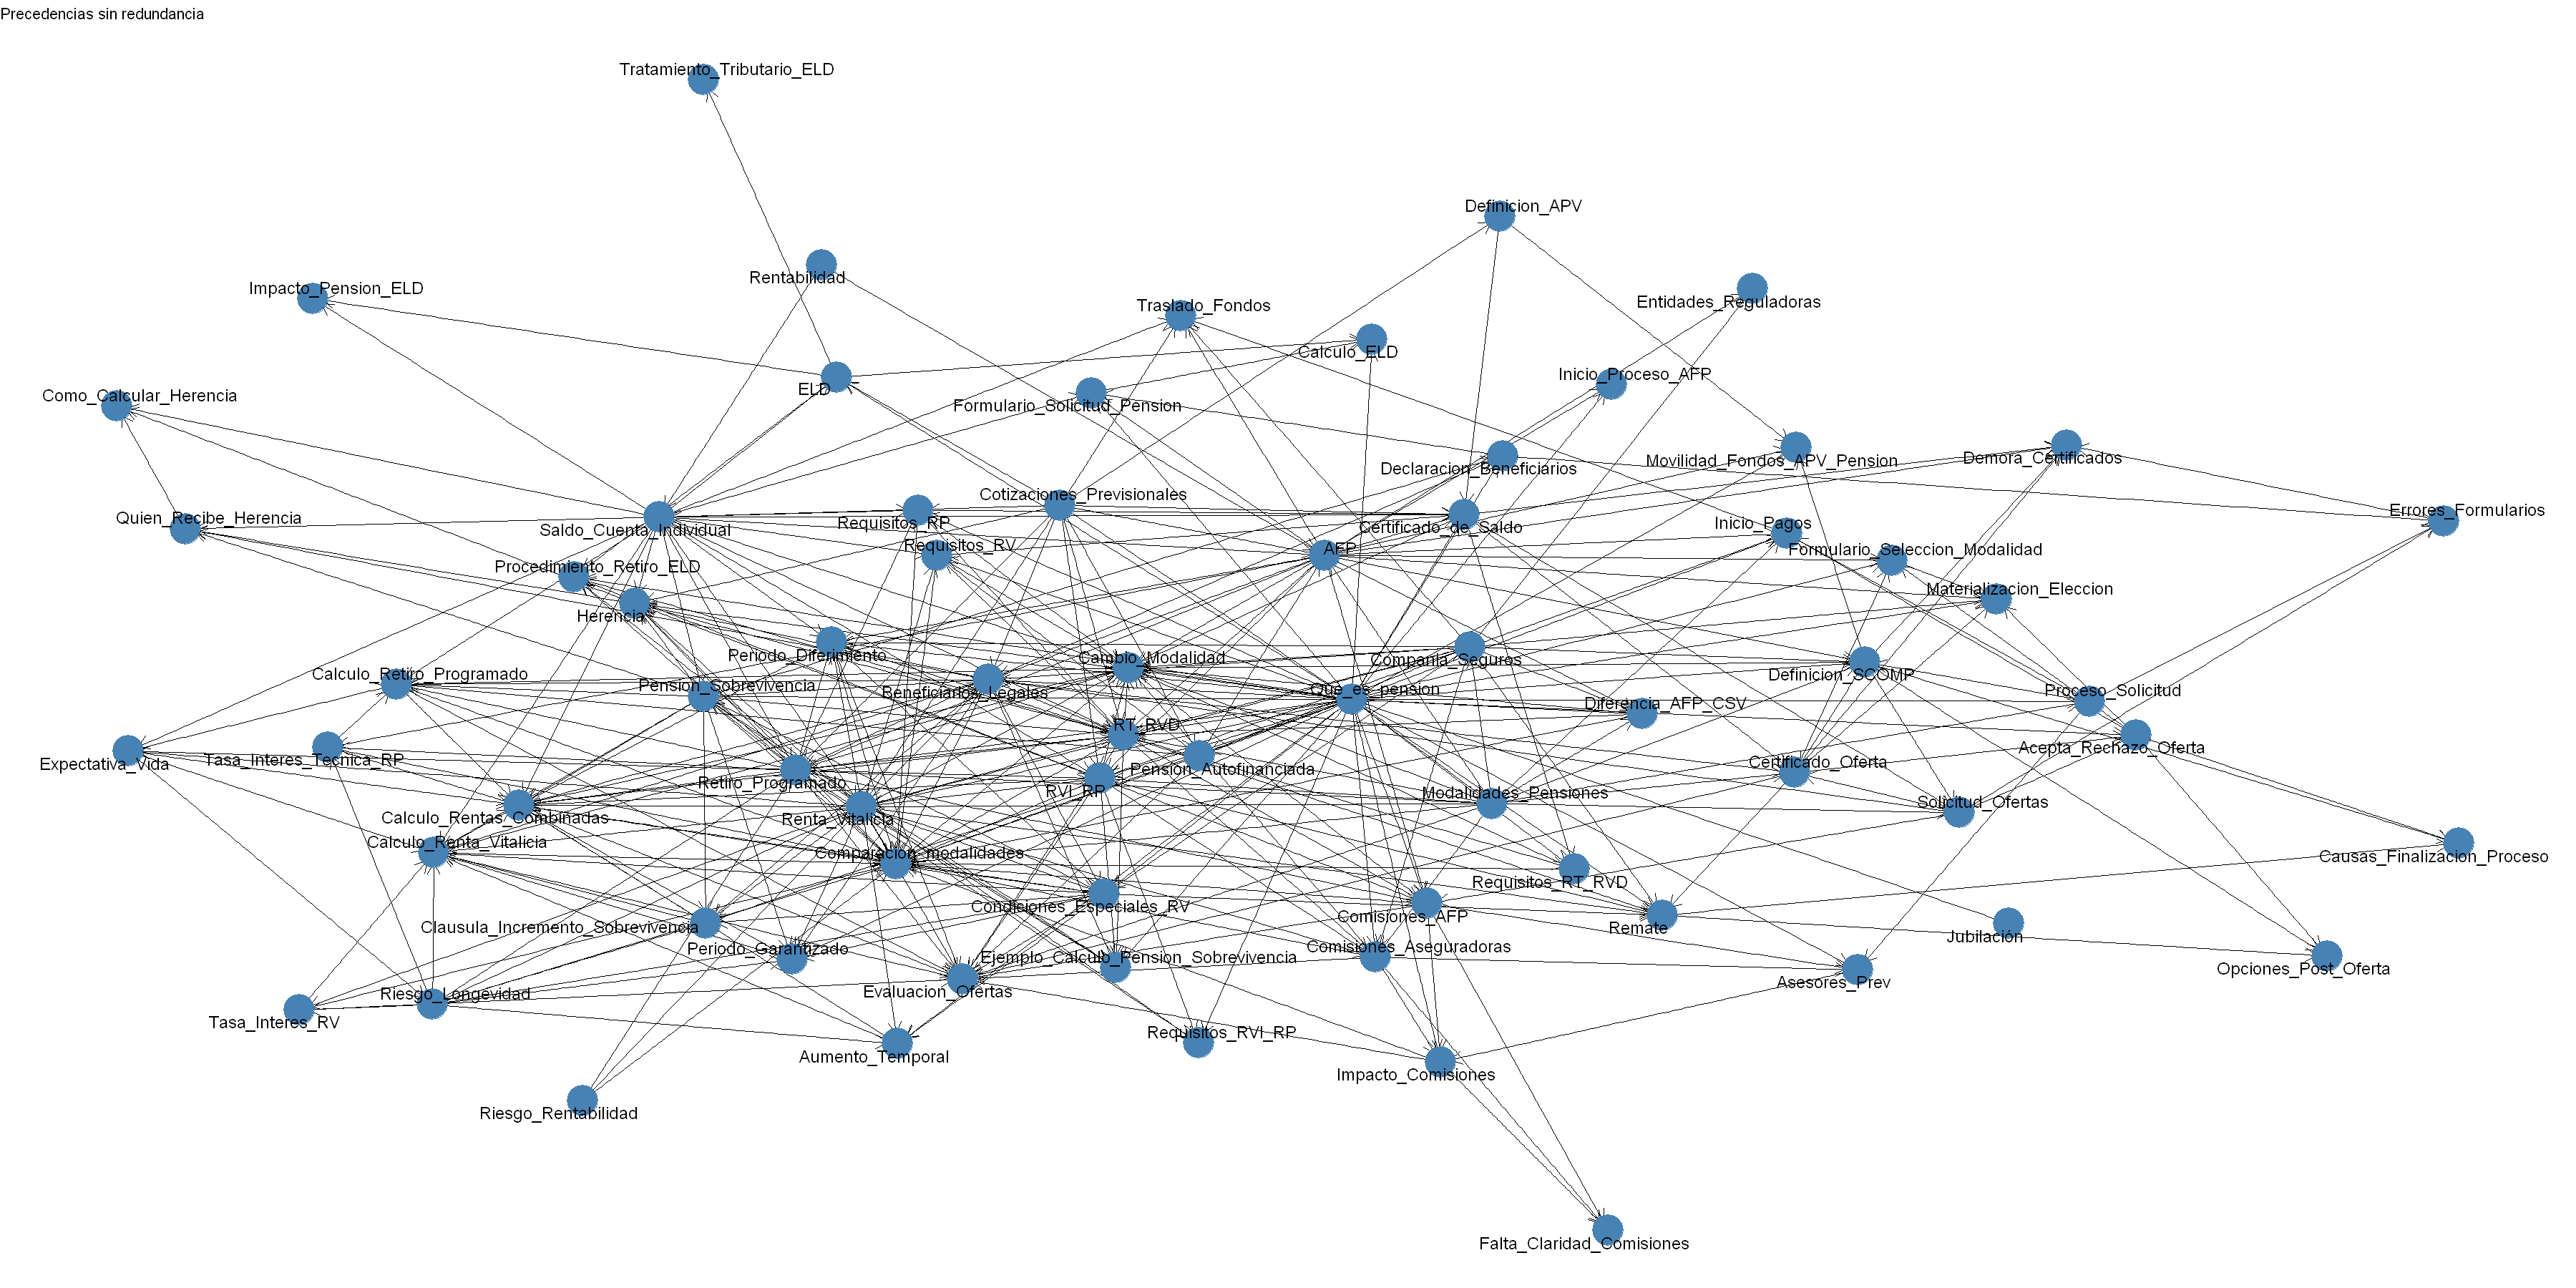

In [61]:
options(repr.plot.width = 30, repr.plot.height = 15)
# Convertir tu grafo igraph a tidygraph
grafo_tidy <- as_tbl_graph(g)

# Visualizar
ggraph(grafo_tidy) +
  geom_edge_link(arrow = arrow(length = unit(4, 'mm')), end_cap = circle(3, 'mm')) +
  geom_node_point(size = 12, color = "steelblue") +
  geom_node_text(aes(label = name), repel = TRUE, size = 5, max.overlaps = Inf) +
  theme_void() +
  ggtitle("Precedencias sin redundancia")

In [49]:
nodos_subgrafo <- c(
  "Que_es_pension",
  "Proceso_Solicitud",
  "Definicion_SCOMP",
  "Evaluacion_Ofertas",
  "Cotizaciones_Previsionales",
  "Modalidades_Pensiones",
  "Renta_Vitalicia",
  "Retiro_Programado",
  "RVI_RP",
  "RT_RVD",
  "Beneficiarios_Legales",
  "Pension_Sobrevivencia",
  "Asesores_Prev"
)

# Nos quedamos solo con los nodos que realmente existen en el grafo
nodos_existentes <- intersect(nodos_subgrafo, V(g)$name)

g_sub <- induced_subgraph(g, vids = nodos_existentes)

vcount(g_sub); ecount(g_sub)


[1] 13

[1] 40

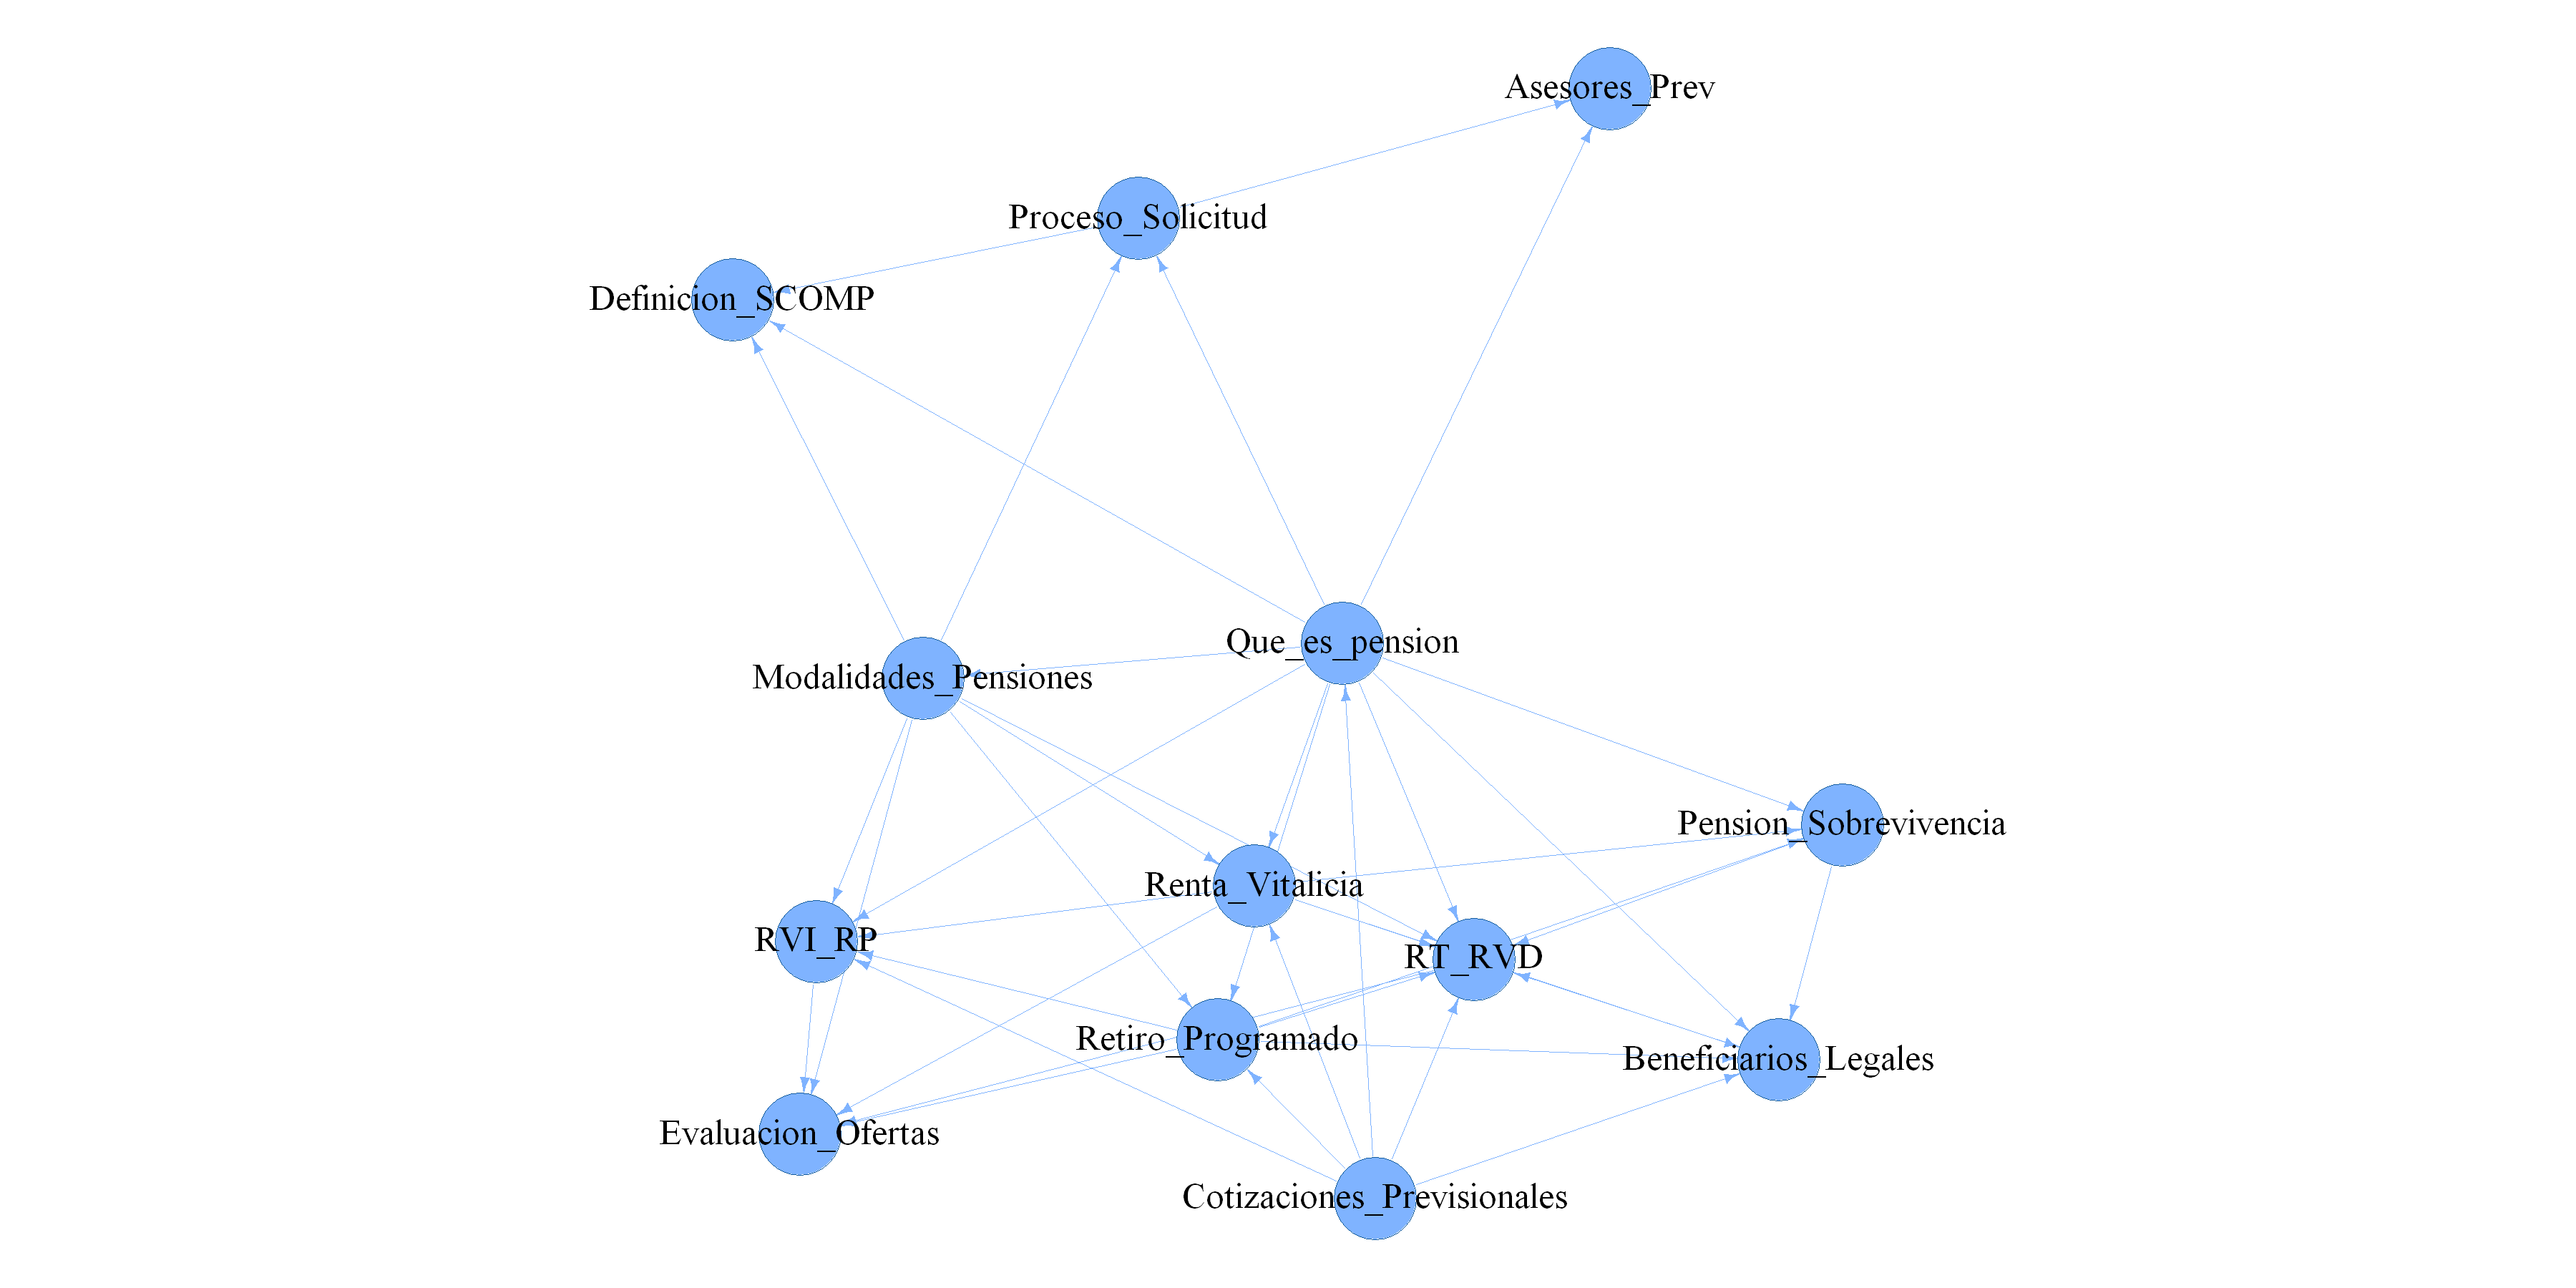

In [50]:
# Layout tipo Fruchterman-Reingold (parecido a spring_layout)
set.seed(7)
lay <- layout_with_fr(g_sub)

# Para que quede sin bordes alrededor
par(mar = c(0, 0, 0, 0))

plot(
  g_sub,
  layout = lay,
  vertex.size = 15,                 # tamaño del círculo
  vertex.color = "#7fb3ff",         # azul del nodo
  vertex.frame.color = "#145c9e",   # borde más oscuro
  vertex.label.color = "black",     # texto blanco
  vertex.label.cex = 2.5,           # tamaño del texto
  #vertex.label.dist = 1.5,          # distancia del texto al nodo
  #vertex.label.degree = 20,            # posición del texto
  edge.color = "#7fb3ff",
  edge.arrow.size = 0.4,            # tamaño de la punta de flecha
  edge.curved = 0                   # líneas rectas
)


In [63]:
# Lee un archivo Excel ubicado en la ruta especificada
matriz <- read_excel(
    "C:/Users/cfutr/OneDrive/Escritorio/CICS/2025/Tesis/Objetivos de Aprendizaje/Modelo/datos/Intermedias/matriz_sin_redundancia_v2.xlsx", col_names=TRUE)

In [64]:
# Toma el data frame `matriz` (cargado desde un archivo Excel previamente)
# y lo transforma en una matriz de adyacencia numérica.

matriz_adj<-matriz%>%
  column_to_rownames(var = colnames(.)[1])%>% #Convierte la primera columna (por ejemplo, "Concepto") en los nombres de las filas.                         
  mutate(across(everything(), as.numeric)) %>%  #Aplica `as.numeric()` a todas las columnas del data frame.
  as.matrix() #Convierte el data frame limpio en una matriz

# Reemplaza todos los valores NA (valores perdidos) en la matriz de adyacencia `matriz_adj` por ceros.
matriz_adj[is.na(matriz_adj)] <- 0

# Crea un grafo dirigido (objeto de clase `igraph`) a partir de la matriz de adyacencia `matriz_adj`.
g <- graph_from_adjacency_matrix(matriz_adj, mode = "directed")

Using "stress" as default layout


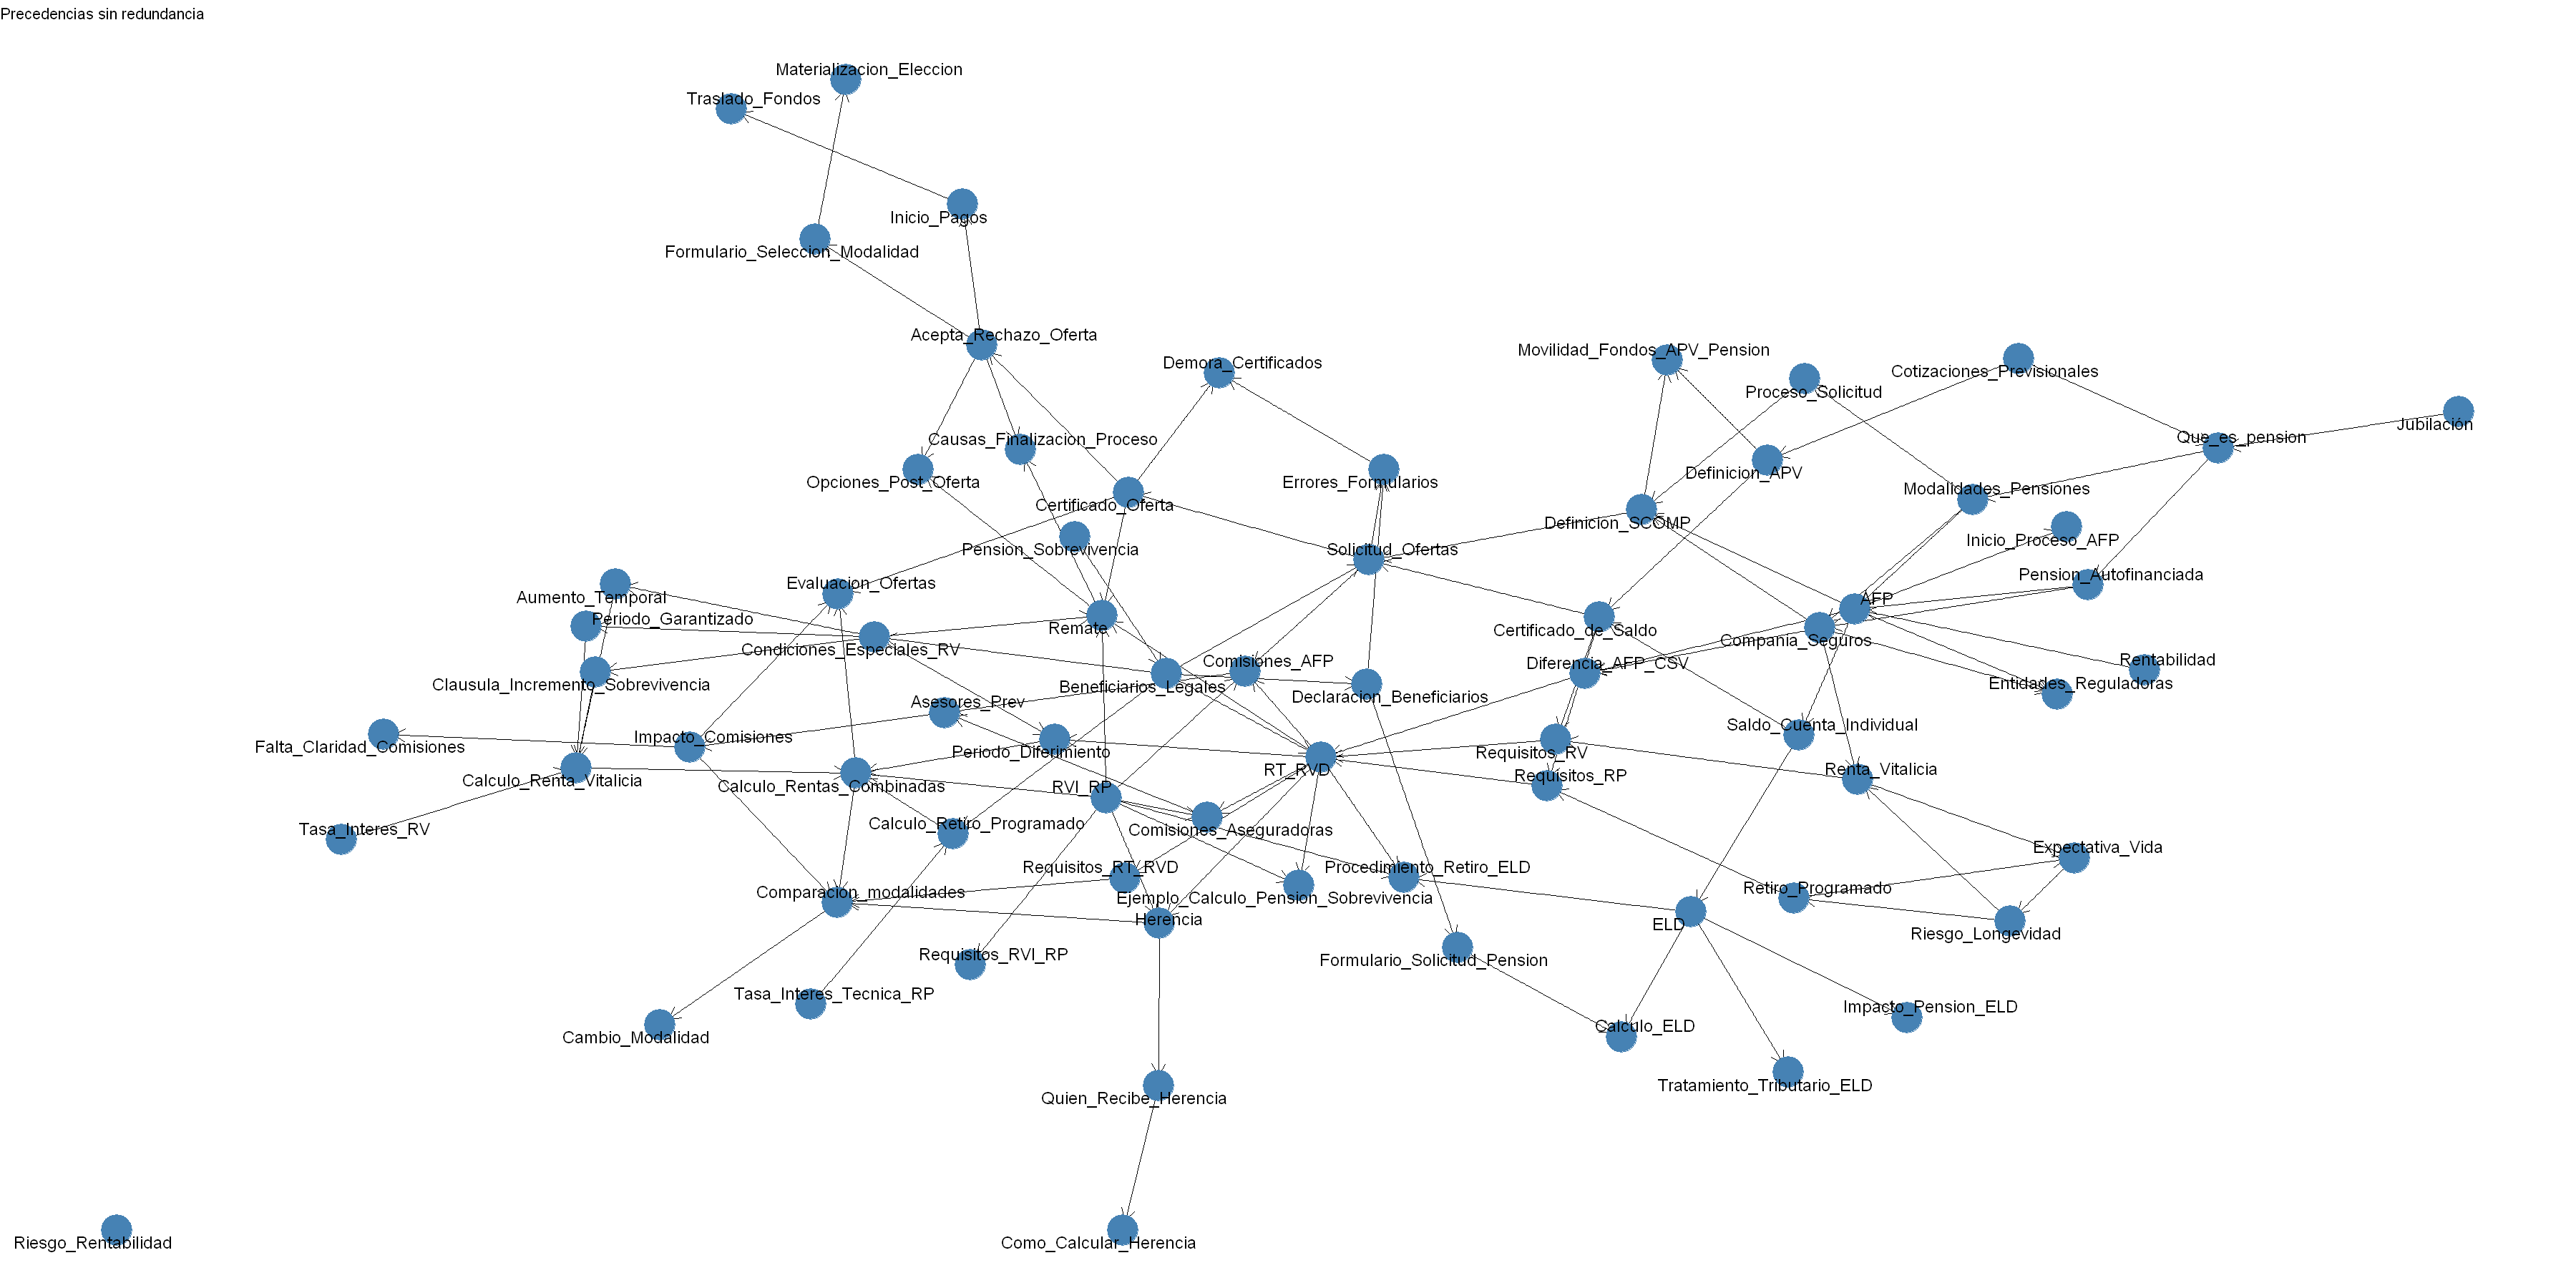

In [65]:
options(repr.plot.width = 30, repr.plot.height = 15)
# Convertir tu grafo igraph a tidygraph
grafo_tidy <- as_tbl_graph(g)

# Visualizar
ggraph(grafo_tidy) +
  geom_edge_link(arrow = arrow(length = unit(4, 'mm')), end_cap = circle(3, 'mm')) +
  geom_node_point(size = 12, color = "steelblue") +
  geom_node_text(aes(label = name), repel = TRUE, size = 5, max.overlaps = Inf) +
  theme_void() +
  ggtitle("Precedencias sin redundancia")

In [43]:
nodos_subgrafo <- c(
  "Que_es_pension",
  "Proceso_Solicitud",
  "Definicion_SCOMP",
  "Evaluacion_Ofertas",
  "Cotizaciones_Previsionales",
  "Modalidades_Pensiones",
  "Renta_Vitalicia",
  "Retiro_Programado",
  "RVI_RP",
  "RT_RVD",
  "Beneficiarios_Legales",
  "Pension_Sobrevivencia",
  "Asesores_Prev"
)

# Nos quedamos solo con los nodos que realmente existen en el grafo
nodos_existentes <- intersect(nodos_subgrafo, V(g)$name)

g_sub <- induced_subgraph(g, vids = nodos_existentes)

vcount(g_sub); ecount(g_sub)

[1] 13

[1] 6

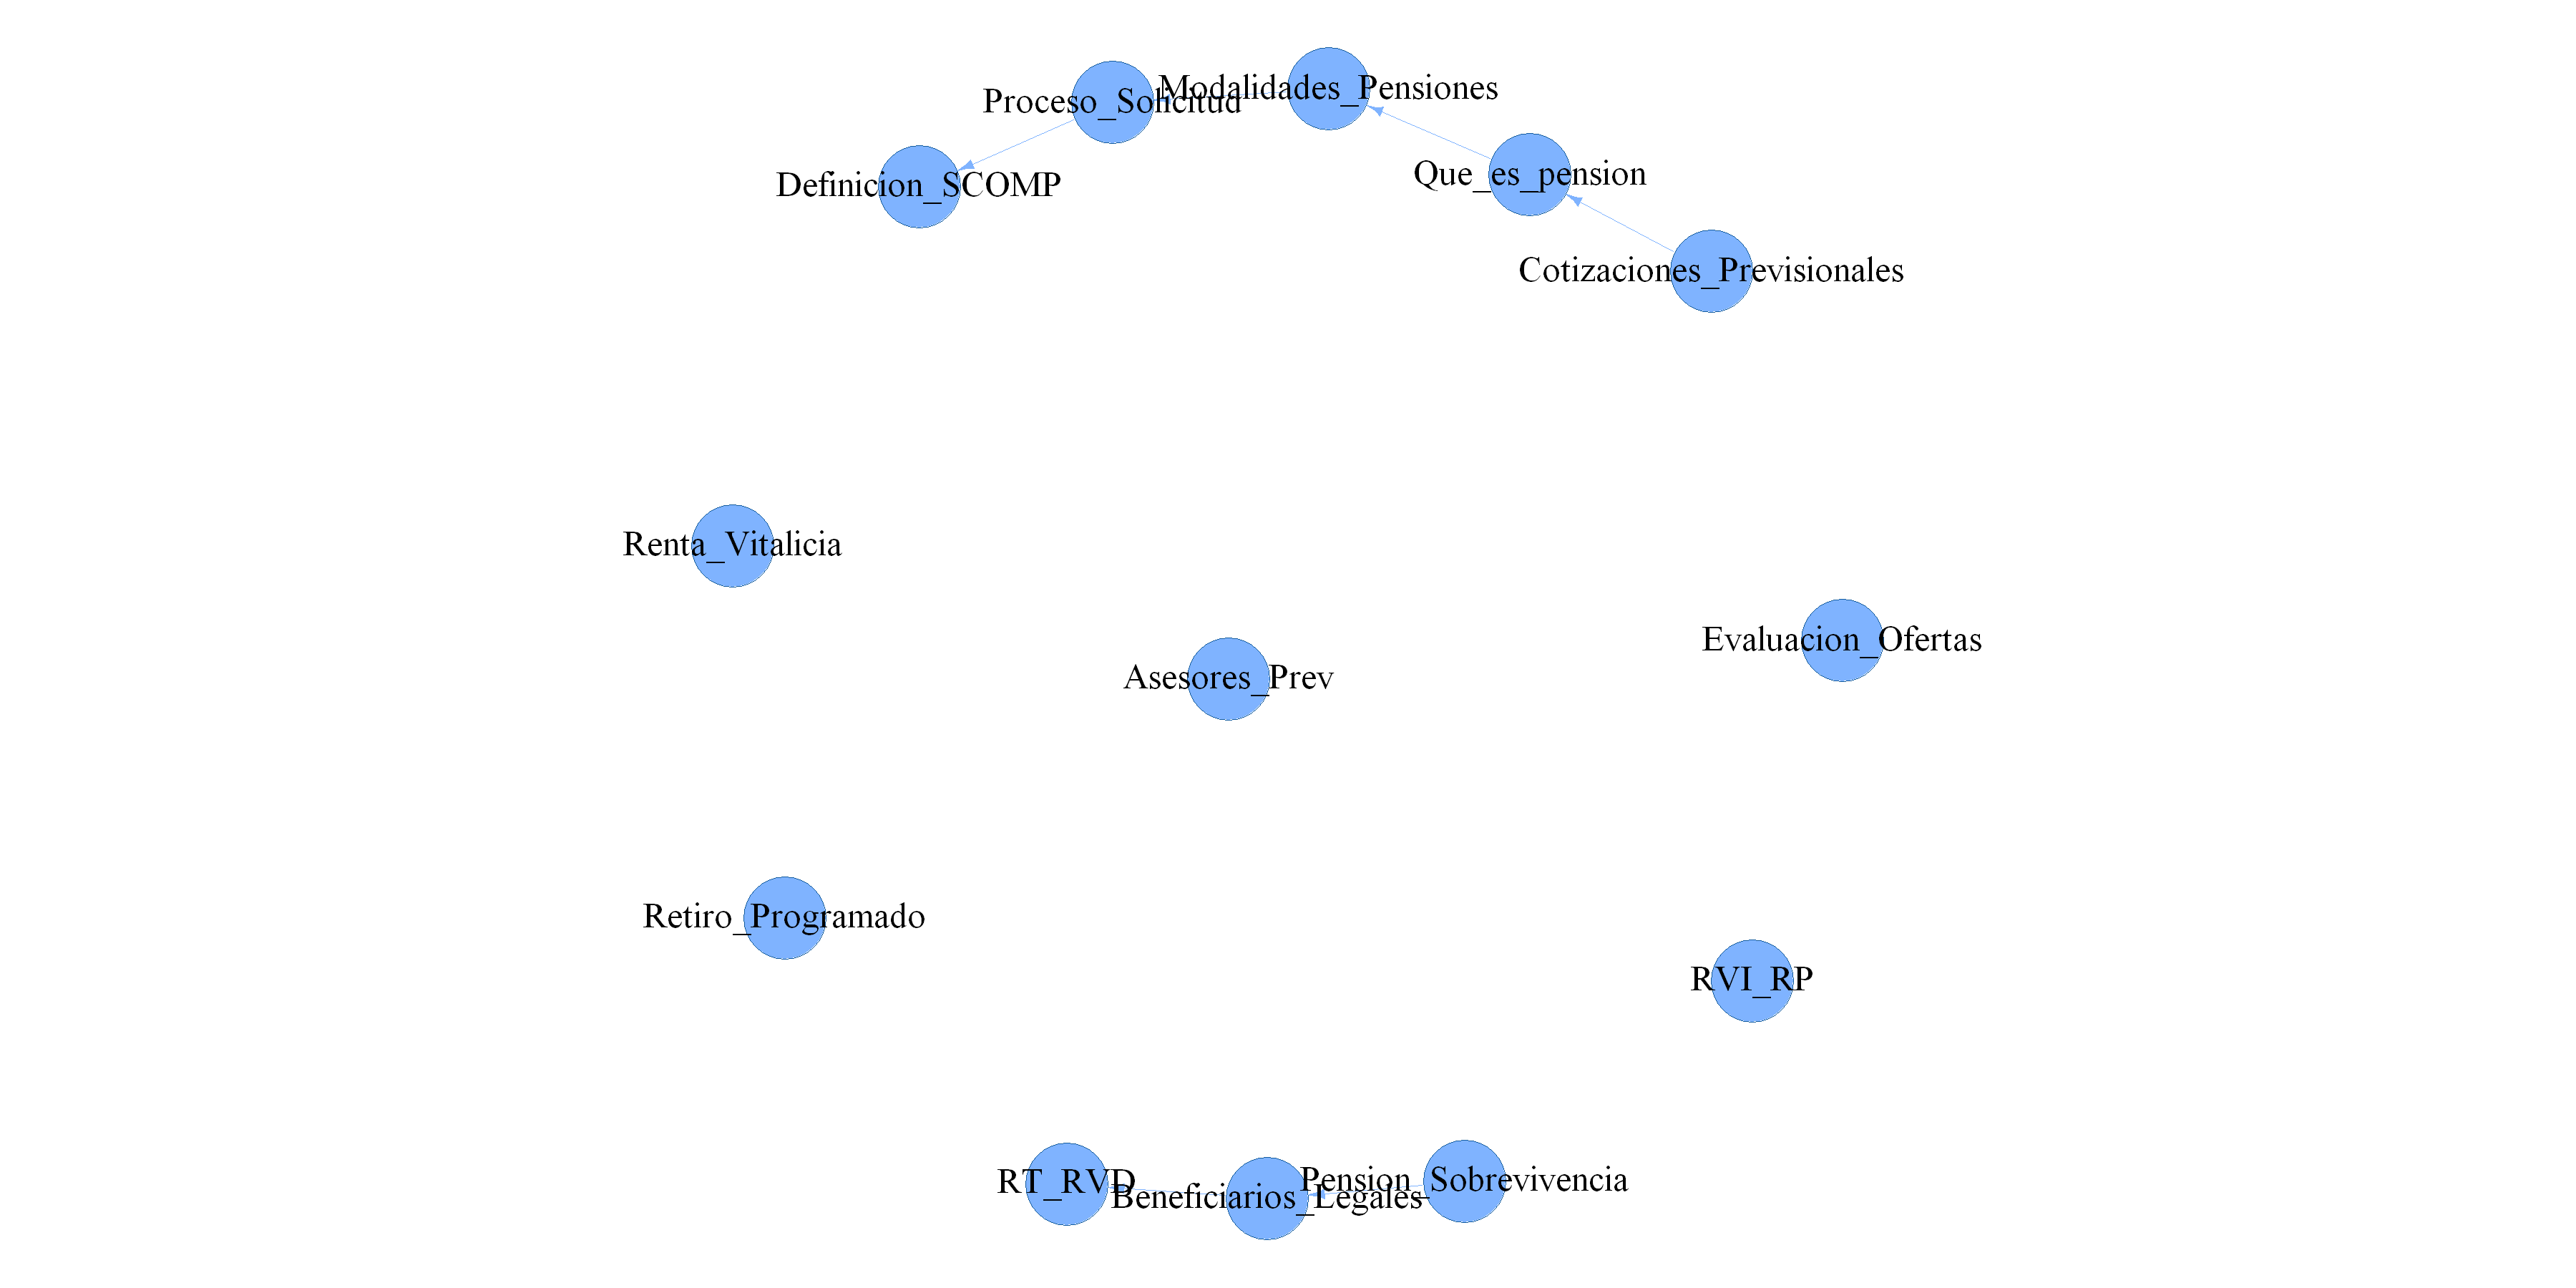

In [44]:
# Layout tipo Fruchterman-Reingold (parecido a spring_layout)
set.seed(7)
lay <- layout_with_fr(g_sub)

# Para que quede sin bordes alrededor
par(mar = c(0, 0, 0, 0))

plot(
  g_sub,
  layout = lay,
  vertex.size = 15,                 # tamaño del círculo
  vertex.color = "#7fb3ff",         # azul del nodo
  vertex.frame.color = "#145c9e",   # borde más oscuro
  vertex.label.color = "black",     # texto blanco
  vertex.label.cex = 2.5,           # tamaño del texto
  #vertex.label.dist = 1.5,          # distancia del texto al nodo
  #vertex.label.degree = 20,            # posición del texto
  edge.color = "#7fb3ff",
  edge.arrow.size = 0.4,            # tamaño de la punta de flecha
  edge.curved = 0                   # líneas rectas
)


In [66]:
library(igraph)

# g_sub: grafo dirigido ya definido con tus conceptos

cent_tbl <- data.frame(
  nodo          = V(g)$name,
  degree_in     = degree(g, mode = "in"),   # cuántos llegan al nodo
  degree_out    = degree(g, mode = "out"),  # cuántos salen del nodo
  degree_total  = degree(g, mode = "all"),  # grado total
  betweenness   = betweenness(
                    g,
                    directed   = TRUE,
                    normalized = TRUE
                  ),
  closeness_out = closeness(
                    g,
                    mode       = "out",
                    normalized = TRUE
                  ),
  eigenvector   = eigen_centrality(
                    g,
                    directed = TRUE,
                    scale    = TRUE
                  )$vector,
  pagerank      = page_rank(
                    g,
                    directed = TRUE
                  )$vector
)

# Ordenar, por ejemplo, por betweenness (nodos “puente” más arriba)
cent_tbl <- cent_tbl[order(-cent_tbl$betweenness), ]

# Redondear para que quede bonito
num_cols <- sapply(cent_tbl, is.numeric)
cent_tbl[num_cols] <- lapply(cent_tbl[num_cols], round, 3)

cent_tbl


,nodo,degree_in,degree_out,degree_total,betweenness,closeness_out,eigenvector,pagerank
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
RT_RVD,RT_RVD,4,8,12,0.066,0.528,0.392,0.044
Solicitud_Ofertas,Solicitud_Ofertas,3,3,6,0.039,0.367,0.000,0.019
AFP,AFP,3,5,8,0.030,0.302,0.000,0.018
Diferencia_AFP_CSV,Diferencia_AFP_CSV,2,1,3,0.025,0.357,0.000,0.011
Certificado_Oferta,Certificado_Oferta,1,4,5,0.024,0.556,0.000,0.011
Definicion_SCOMP,Definicion_SCOMP,3,2,5,0.022,0.290,0.000,0.018
Certificado_de_Saldo,Certificado_de_Saldo,2,3,5,0.021,0.307,0.000,0.012
Compania_Seguros,Compania_Seguros,2,4,6,0.018,0.289,0.000,0.013
Acepta_Rechazo_Oferta,Acepta_Rechazo_Oferta,1,4,5,0.015,0.750,0.000,0.008


In [67]:
write.csv(cent_tbl, "../../datos/Intermedias/centralidad_conceptos_sin_ciclos.csv", row.names = FALSE)


## Vamos a implementar un modelo de juguete! 

Instalación y lectura de paquetes

In [ ]:
#install.packages(c("ompr", "ompr.roi", "ROI", "ROI.plugin.glpk", "igraph"))


Warning message:
"package 'igraph' is in use and will not be installed"
Installing packages into 'C:/Users/cfutr/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)

also installing the dependencies 'listcomp', 'slam', 'registry', 'checkmate', 'Rglpk'




package 'listcomp' successfully unpacked and MD5 sums checked
package 'slam' successfully unpacked and MD5 sums checked
package 'registry' successfully unpacked and MD5 sums checked
package 'checkmate' successfully unpacked and MD5 sums checked
package 'Rglpk' successfully unpacked and MD5 sums checked
package 'ompr' successfully unpacked and MD5 sums checked
package 'ompr.roi' successfully unpacked and MD5 sums checked
package 'ROI' successfully unpacked and MD5 sums checked
package 'ROI.plugin.glpk' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\cfutr\AppData\Local\Temp\Rtmp4GdnTf\downloaded_packages


In [72]:
library(ompr)
library(ompr.roi)
library(ROI)
library(ROI.plugin.glpk)
library(igraph)


Warning message:
"package 'ompr' was built under R version 4.5.2"
Warning message:
"package 'ompr.roi' was built under R version 4.5.2"
Warning message:
"package 'ROI' was built under R version 4.5.2"
ROI: R Optimization Infrastructure

Registered solver plugins: nlminb, glpk.

Default solver: auto.

Warning message:
"package 'ROI.plugin.glpk' was built under R version 4.5.2"


- Lee la matriz de precedencias 
- Lee el archivo con los parámetros (importancia y tiempo) 
- elije los conceptos que van a ir al modelo

In [141]:
# Lee matriz de precedencia
mat_raw <- read_excel("C:/Users/cfutr/OneDrive/Escritorio/CICS/2025/Tesis/Objetivos de Aprendizaje/Modelo/datos/Raw_Data/Matriz_de_Adyacencia_Pensiones_v5.xlsx", sheet = 1)

# Renombrar la primera columna como 'Concepto' (ajusta si quieres por nombre)
names(mat_raw)[1] <- "Concepto"

# Guardamos los nombres de los conceptos
concept_names <- mat_raw$Concepto

# Quitamos la columna de nombres para quedarnos solo con 0/1
mat_vals <- mat_raw[, -1]

# Convertimos todo a numérico
mat_vals <- as.data.frame(lapply(mat_vals, as.numeric))

# Reemplazamos NA por 0 (sin precedencia)
mat_vals[is.na(mat_vals)] <- 0

# Convertimos a matriz
P <- as.matrix(mat_vals)

# Asignamos nombres de filas y columnas
rownames(P) <- concept_names
colnames(P) <- colnames(mat_vals)

# Revisar dimensiones y primeras celdas
dim(P)
P[1:5, 1:5]



[1] 71 71

,Jubilación,Rentabilidad,Que_es_pension,Pension_Autofinanciada,Entidades_Reguladoras
Jubilación,0,0,1,0,0
Rentabilidad,0,0,0,0,0
Que_es_pension,0,0,0,1,0
Pension_Autofinanciada,0,0,0,0,0
Entidades_Reguladoras,0,0,0,0,0


In [142]:
conceptos <- read_excel("C:/Users/cfutr/OneDrive/Escritorio/CICS/2025/Tesis/Objetivos de Aprendizaje/Modelo/datos/Intermedias/conceptos.xlsx", sheet = 1)

# Revisa que estén las columnas
names(conceptos)
head(conceptos)
conceptos <- conceptos %>%
  rename(Concepto = Recurso)

names(conceptos)
head(conceptos)


[1] "ID"              "Recurso"         "Tiempo_Estimado" "Importancia"

ID,Recurso,Tiempo_Estimado,Importancia
<dbl>,<chr>,<dbl>,<dbl>
1,Que_es_pension,100,41
2,Proceso_Solicitud,195,4
3,Definicion_SCOMP,93,7
4,Evaluacion_Ofertas,48,0
5,Cotizaciones_previsionales,88,14
6,Modalidades_Pensiones,260,16


[1] "ID"              "Concepto"        "Tiempo_Estimado" "Importancia"

ID,Concepto,Tiempo_Estimado,Importancia
<dbl>,<chr>,<dbl>,<dbl>
1,Que_es_pension,100,41
2,Proceso_Solicitud,195,4
3,Definicion_SCOMP,93,7
4,Evaluacion_Ofertas,48,0
5,Cotizaciones_previsionales,88,14
6,Modalidades_Pensiones,260,16


In [146]:
sub_conceptos <- c(
  "Que_es_pension",
  "Proceso_Solicitud",
  "Definicion_SCOMP",
  "Evaluacion_Ofertas",
  "Cotizaciones_previsionales",
  "Modalidades_Pensiones",
  "Renta_Vitalicia",
  "Retiro_Programado",
  "RVI_RP",
  "RT_RVD",
  "Beneficiarios_Legales",
  "Pension_Sobrevivencia",
  "Asesores_Prev"
  # agrega/quita según tu necesidad
)


In [147]:
# 4.1 Filtrar tabla de conceptos al subgrupo
conceptos_sub <- conceptos %>%
  filter(Concepto %in% sub_conceptos)

conceptos_sub

ID,Concepto,Tiempo_Estimado,Importancia
<dbl>,<chr>,<dbl>,<dbl>
1,Que_es_pension,100,41
2,Proceso_Solicitud,195,4
3,Definicion_SCOMP,93,7
4,Evaluacion_Ofertas,48,0
5,Cotizaciones_previsionales,88,14
6,Modalidades_Pensiones,260,16
7,Renta_Vitalicia,106,23
8,Retiro_Programado,94,18
9,RVI_RP,86,11


In [148]:
# 4.2 Aseguramos que el orden en P siga el orden de conceptos_sub
nombres_sub <- conceptos_sub$Concepto

# Verificamos que todos los del subgrupo estén en P
all(nombres_sub %in% rownames(P))
# si esto da FALSE, hay un problema de nombres que no calzan exactamente

# Creamos el vector de índices de fila/columna en P
orden <- match(nombres_sub, rownames(P))

# Submatriz de precedencias solo para el subgrupo
P_sub <- P[orden, orden]

rownames(P_sub) <- nombres_sub
colnames(P_sub) <- nombres_sub

# Revisión rápida
dim(P_sub)
P_sub


[1] TRUE

[1] 13 13

,Que_es_pension,Proceso_Solicitud,Definicion_SCOMP,Evaluacion_Ofertas,Cotizaciones_previsionales,Modalidades_Pensiones,Renta_Vitalicia,Retiro_Programado,RVI_RP,RT_RVD,Beneficiarios_Legales,Pension_Sobrevivencia,Asesores_Prev
Que_es_pension,0,1,1,0,0,1,1,1,1,1,1,1,1
Proceso_Solicitud,0,0,1,0,0,0,0,0,0,0,0,0,1
Definicion_SCOMP,0,0,0,0,0,0,0,0,0,0,0,0,0
Evaluacion_Ofertas,0,0,0,0,0,0,0,0,0,0,0,0,0
Cotizaciones_previsionales,1,0,0,0,0,0,1,1,1,1,1,0,0
Modalidades_Pensiones,0,1,1,1,0,0,1,1,1,1,0,0,0
Renta_Vitalicia,0,0,0,1,0,0,0,0,1,1,1,1,0
Retiro_Programado,0,0,0,1,0,0,0,0,1,1,1,1,0
RVI_RP,0,0,0,1,0,0,0,0,0,0,0,0,0
RT_RVD,0,0,0,1,0,0,0,0,0,0,0,0,0


In [149]:
idx <- which(P_sub == 1, arr.ind = TRUE)

arcos <- data.frame(
  i = idx[, "row"],  # índice del prerequisito (1..n_sub)
  j = idx[, "col"]   # índice del dependiente (1..n_sub)
)

arcos

i,j
<int>,<int>
5,1
1,2
6,2
1,3
2,3
6,3
6,4
7,4
8,4


In [150]:
n  <- nrow(conceptos_sub)

tiempos      <- as.numeric(conceptos_sub$Tiempo_Estimado)
importancias <- as.numeric(conceptos_sub$Importancia)

tiempos
importancias


[1] 100 195  93  48  88 260 106  94  86 110  94 109  55

[1] 41  4  7  0 14 16 23 18 11 12 14 13  1

In [164]:
T_max <- 900  # AJUSTA este valor según tu escala de Tiempo_Estimado

model <- MIPModel() %>%
  # variables x[i] ∈ {0,1}
  add_variable(x[i], i = 1:n, type = "binary") %>%
  
  # restricción de tiempo total
  add_constraint(
    sum_expr(tiempos[i] * x[i], i = 1:n) <= T_max
  )

# Solo agregamos restricciones de precedencia si hay arcos
if (nrow(arcos) > 0) {
  model <- model %>%
    add_constraint(
      x[arcos$j[k]] <= x[arcos$i[k]],
      k = 1:nrow(arcos)
    )
}

# objetivo: maximizar importancia total
model <- model %>%
  set_objective(
    sum_expr(importancias[i] * x[i], i = 1:n),
    sense = "max"
  )

sol <- solve_model(model, with_ROI(solver = "glpk", verbose = TRUE))
sol$status


<SOLVER MSG>  ----
GLPK Simplex Optimizer 5.0
41 rows, 13 columns, 93 non-zeros
*     0: obj =  -0.000000000e+00 inf =   0.000e+00 (12)
*    12: obj =   1.453070761e+02 inf =   3.775e-15 (0)
OPTIMAL LP SOLUTION FOUND
GLPK Integer Optimizer 5.0
41 rows, 13 columns, 93 non-zeros
13 integer variables, all of which are binary
Integer optimization begins...
Long-step dual simplex will be used
+    12: mip =     not found yet <=              +inf        (1; 0)
+    16: >>>>>   1.360000000e+02 <=   1.440000000e+02   5.9% (4; 0)
Solution found by heuristic: 139
+    19: mip =   1.390000000e+02 <=     tree is empty   0.0% (0; 9)
INTEGER OPTIMAL SOLUTION FOUND
<!SOLVER MSG> ----


[1] "success"

In [165]:
# 8.1 Extraer solución del modelo
x_vals <- get_solution(sol, x[i])
x_vals
# x_vals tiene columnas: variable, i, value

# Índices de conceptos seleccionados (x[i] ≈ 1)
idx_sel <- x_vals$i[x_vals$value > 0.5]
idx_sel <- as.integer(idx_sel)
idx_sel



,variable,i,value
,<chr>,<int>,<dbl>
1,x,1,1
2,x,2,0
3,x,3,0
4,x,4,0
5,x,5,1
6,x,6,1
7,x,7,1
8,x,8,1
9,x,9,0


[1]  1  5  6  7  8 11 12

In [166]:
# 8.2 Tabla con los conceptos seleccionados
conceptos_sel <- conceptos_sub[idx_sel, ]
conceptos_sel


ID,Concepto,Tiempo_Estimado,Importancia
<dbl>,<chr>,<dbl>,<dbl>
1,Que_es_pension,100,41
5,Cotizaciones_previsionales,88,14
6,Modalidades_Pensiones,260,16
7,Renta_Vitalicia,106,23
8,Retiro_Programado,94,18
11,Beneficiarios_Legales,94,14
12,Pension_Sobrevivencia,109,13


In [167]:
# 8.3 Grafo de precedencias del subgrupo (usando P_sub)
g_sub <- graph_from_adjacency_matrix(P_sub, mode = "directed")

# 8.4 Subgrafo solo con nodos seleccionados
g_sel <- induced_subgraph(g_sub, vids = idx_sel)

# 8.5 Orden topológico (prerrequisitos primero)
orden_topo <- topo_sort(g_sel, mode = "out")
orden_idx  <- as.integer(orden_topo)

# 8.6 Tabla final de secuencia óptima
secuencia_optima <- conceptos_sub[orden_idx, ]
secuencia_optima$Paso <- seq_len(nrow(secuencia_optima))

secuencia_optima <- secuencia_optima[, c("Paso", "Concepto", "Tiempo_Estimado", "Importancia")]
secuencia_optima


Paso,Concepto,Tiempo_Estimado,Importancia
<int>,<chr>,<dbl>,<dbl>
1,Proceso_Solicitud,195,4
2,Que_es_pension,100,41
3,Definicion_SCOMP,93,7
4,Evaluacion_Ofertas,48,0
5,Cotizaciones_previsionales,88,14
6,Renta_Vitalicia,106,23
7,Modalidades_Pensiones,260,16


In [174]:
#library(dplyr)

secuencia_optima_t <- secuencia_optima %>%
  arrange(Paso) %>%
  mutate(
    Duracion = Tiempo_Estimado,
    Inicio   = dplyr::lag(cumsum(Duracion), default = 0),
    Fin      = Inicio + Duracion,
    Etiqueta = paste0(Paso, ". ", Concepto)
  )

secuencia_optima_t


Paso,Concepto,Tiempo_Estimado,Importancia,Duracion,Inicio,Fin,Etiqueta
<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,Proceso_Solicitud,195,4,195,0,195,1. Proceso_Solicitud
2,Que_es_pension,100,41,100,195,295,2. Que_es_pension
3,Definicion_SCOMP,93,7,93,295,388,3. Definicion_SCOMP
4,Evaluacion_Ofertas,48,0,48,388,436,4. Evaluacion_Ofertas
5,Cotizaciones_previsionales,88,14,88,436,524,5. Cotizaciones_previsionales
6,Renta_Vitalicia,106,23,106,524,630,6. Renta_Vitalicia
7,Modalidades_Pensiones,260,16,260,630,890,7. Modalidades_Pensiones


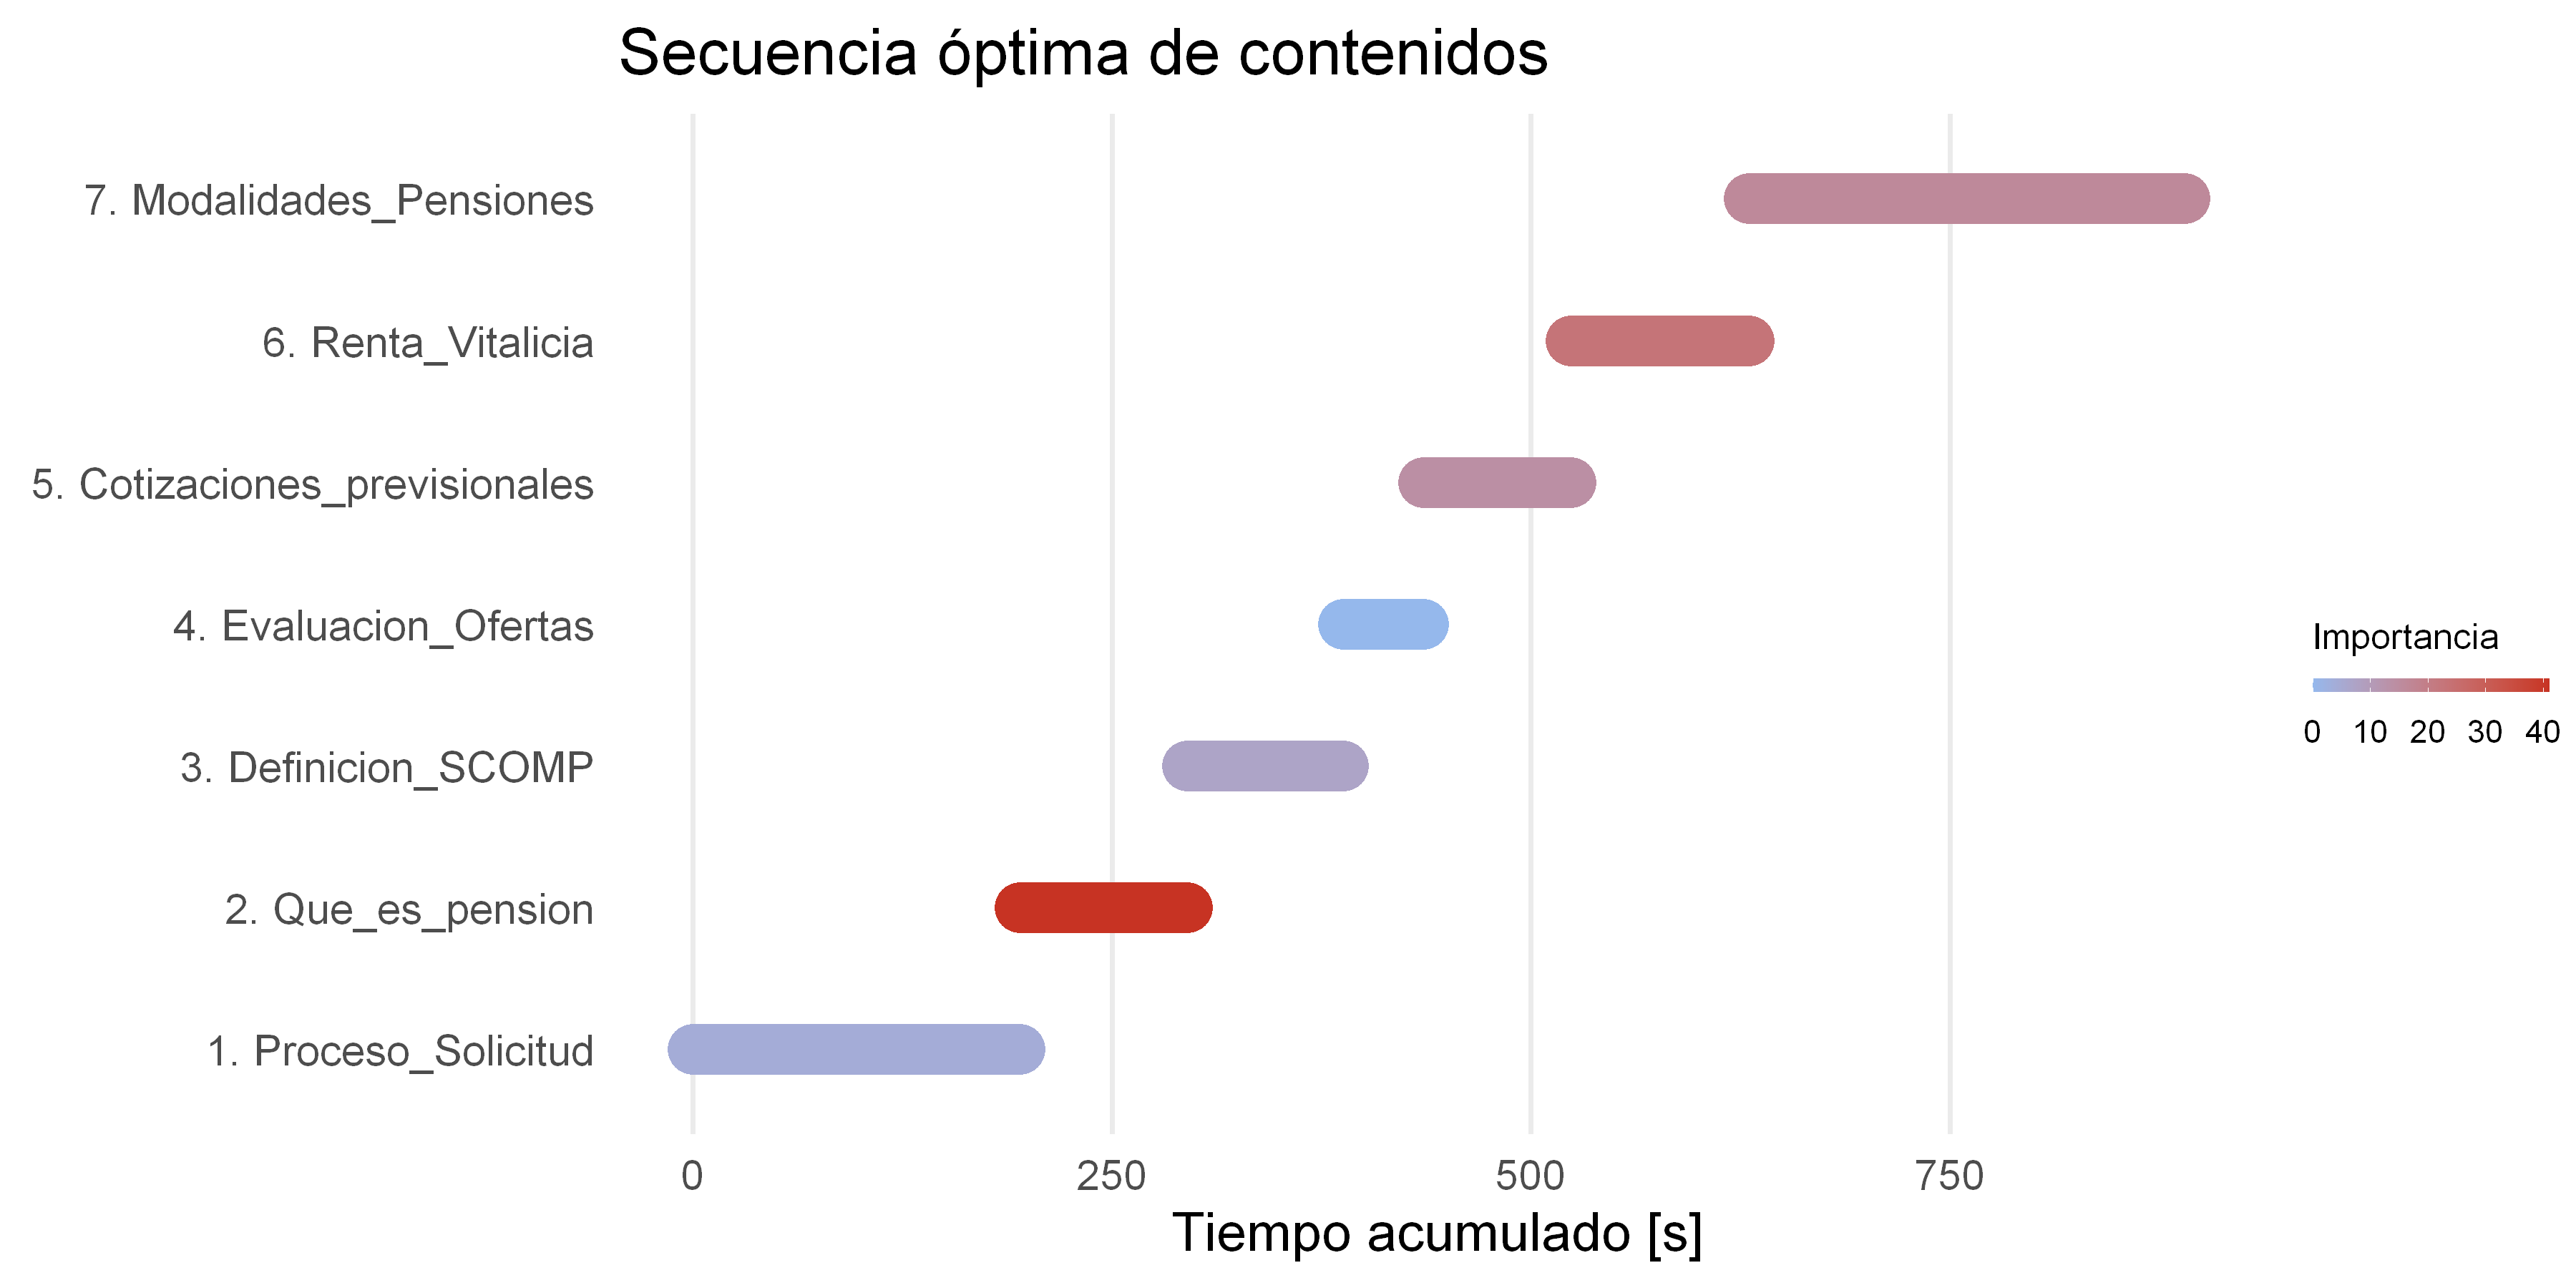

In [205]:
#library(ggplot2)

p_gantt <- ggplot(secuencia_optima_t) +
  # barra por concepto
  geom_segment(
    aes(x = Inicio, xend = Fin,
        y = reorder(Etiqueta, Paso),
        yend = reorder(Etiqueta, Paso),
        colour = Importancia),
    size = 20, lineend = "round"
  ) +
  scale_colour_gradient(
    low  = "#95b8ecff",  # poca importancia  
    high = "#c73323ff",  # alta importancia 
    name = "Importancia"
  ) +
  guides(
    colour = guide_colourbar(
      direction     = "horizontal",
      title.position = "top",
      barwidth      = unit(7, "cm"),
      barheight     = unit(0.4, "cm")
    )
  ) +
  labs(
    x = "Tiempo acumulado [s]",
    y = NULL,
    title = "Secuencia óptima de contenidos"
  ) +
  theme_minimal(base_size = 45) +
  theme(
    panel.grid.minor   = element_blank(),
    panel.grid.major.y = element_blank(),
    legend.position    = "right",
    legend.title       = element_text(size = 30),
    legend.text        = element_text(size = 27),
    legend.margin      = margin(t = 100)
  )

p_gantt
